# Resume Screener AI — dataset audit

Real Kaggle Resume Dataset. This notebook describes the raw data; vocabulary fitting and model selection occur only inside training folds. No raw personal resume text is displayed.

In [1]:
from pathlib import Path
import sys, json
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display, Image
from src.eda import run
stats = run()
df = pd.read_csv(ROOT / 'data/resumes.csv')
display(pd.Series(json.loads((ROOT / 'data/provenance.json').read_text())))

source            https://www.kaggle.com/datasets/snehaanbhawal/...
download_url      https://www.kaggle.com/api/v1/datasets/downloa...
synthetic                                                     False
archive_sha256    b12c4ab34df707ad2cc64312c016509cad9b6c93b0baed...
csv_sha256        76275a0d8e029e4fb46250296c0a25661bd44534ccdec0...
archive_member                                    Resume/Resume.csv
raw_rows                                                       2484
raw_categories                                                   24
transformation    Rename Resume_str to Resume; retain Resume and...
dtype: object

## Category balance
Macro F1 gives each category equal weight despite unequal support.

,resumes
ACCOUNTANT,118
ADVOCATE,118
AGRICULTURE,63
APPAREL,97
ARTS,103
AUTOMOBILE,36
AVIATION,117
BANKING,115
BPO,22
BUSINESS-DEVELOPMENT,120


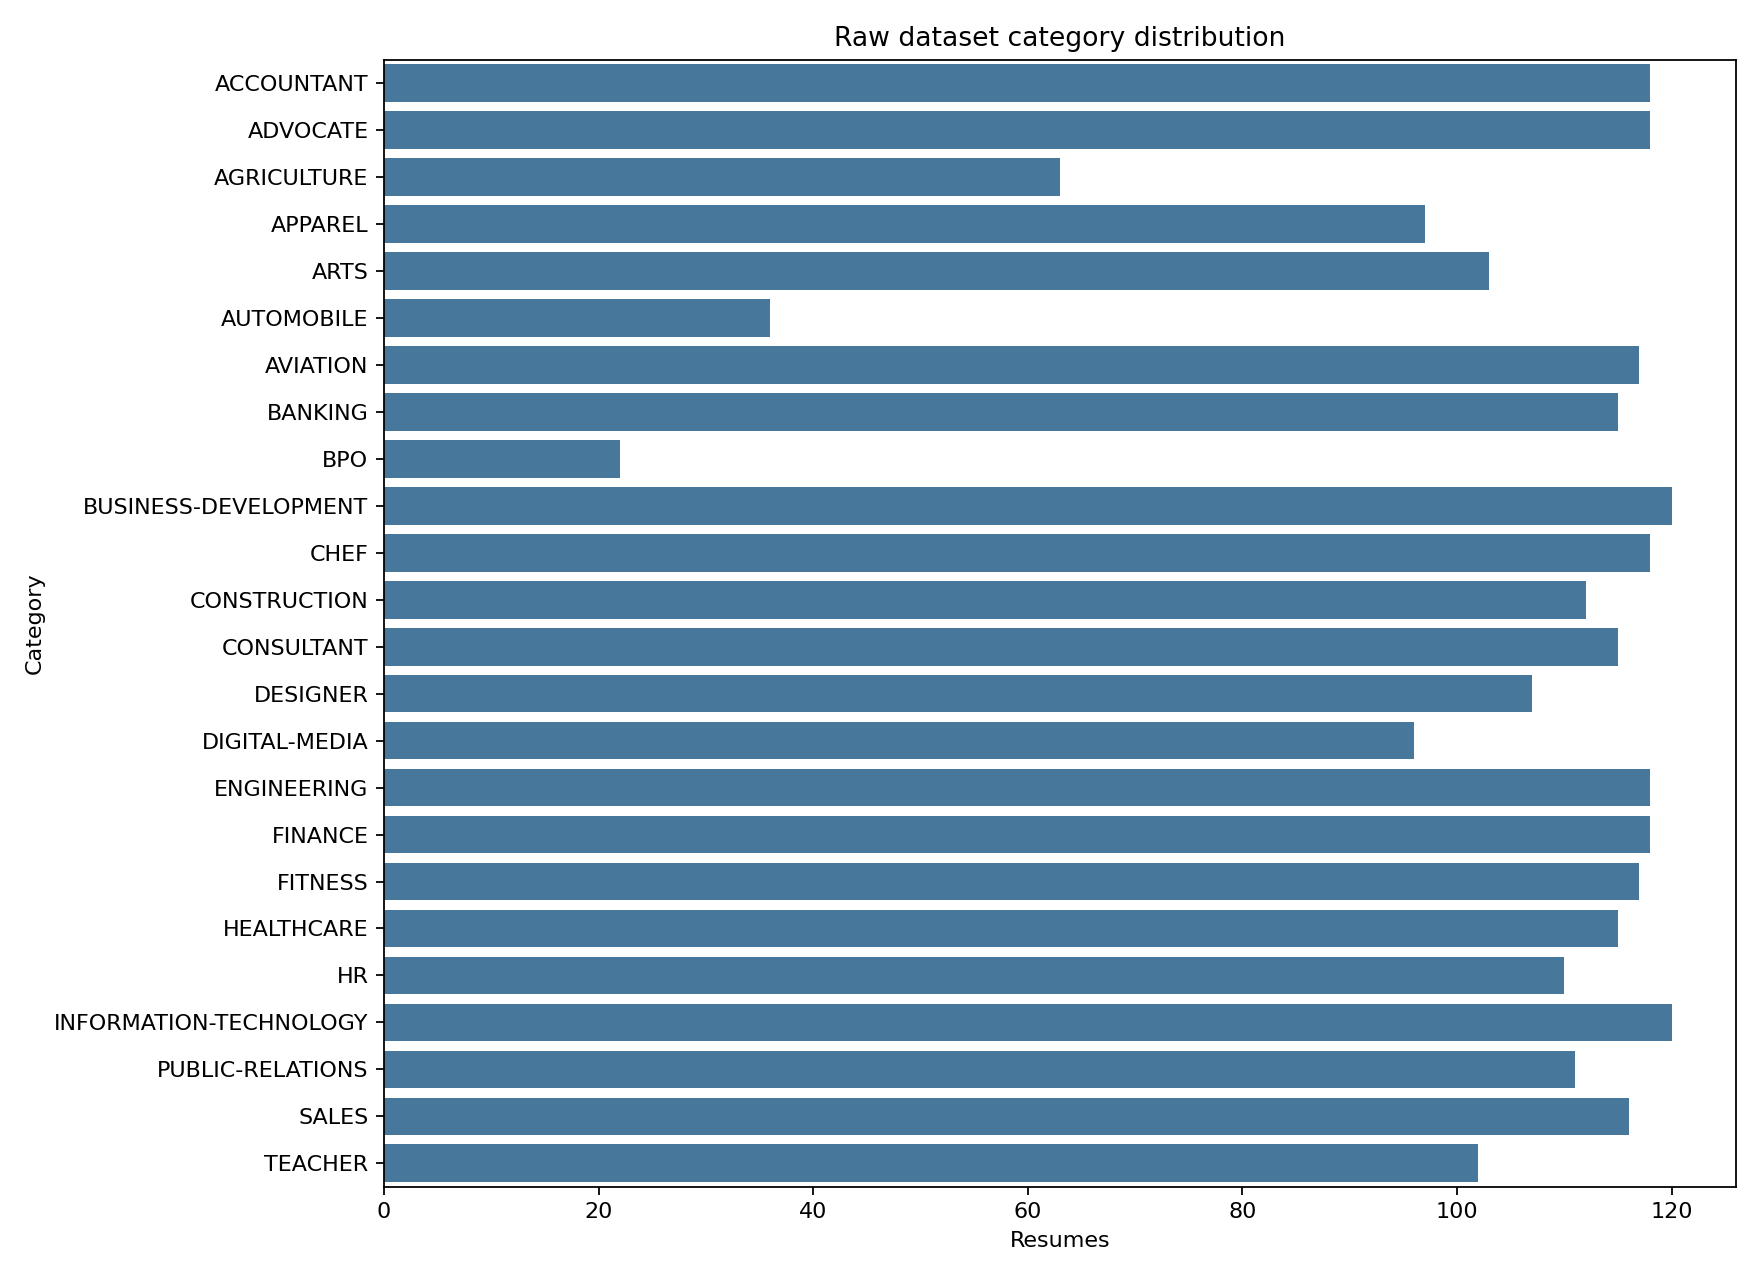

In [2]:
display(pd.Series(stats['category_counts'], name='resumes').to_frame())
display(Image(filename=str(ROOT / 'reports/figures/category_distribution.png')))

## Length and duplication
Whitespace word counts include punctuation; preprocessing has its own token definition. Empty and duplicate cleaned resumes are excluded before the split.

count    2484.000000
mean      811.325684
std       371.006906
min         0.000000
25%       651.000000
50%       757.000000
75%       933.000000
max      5190.000000
Name: words, dtype: float64

Exact duplicate raw texts: 2


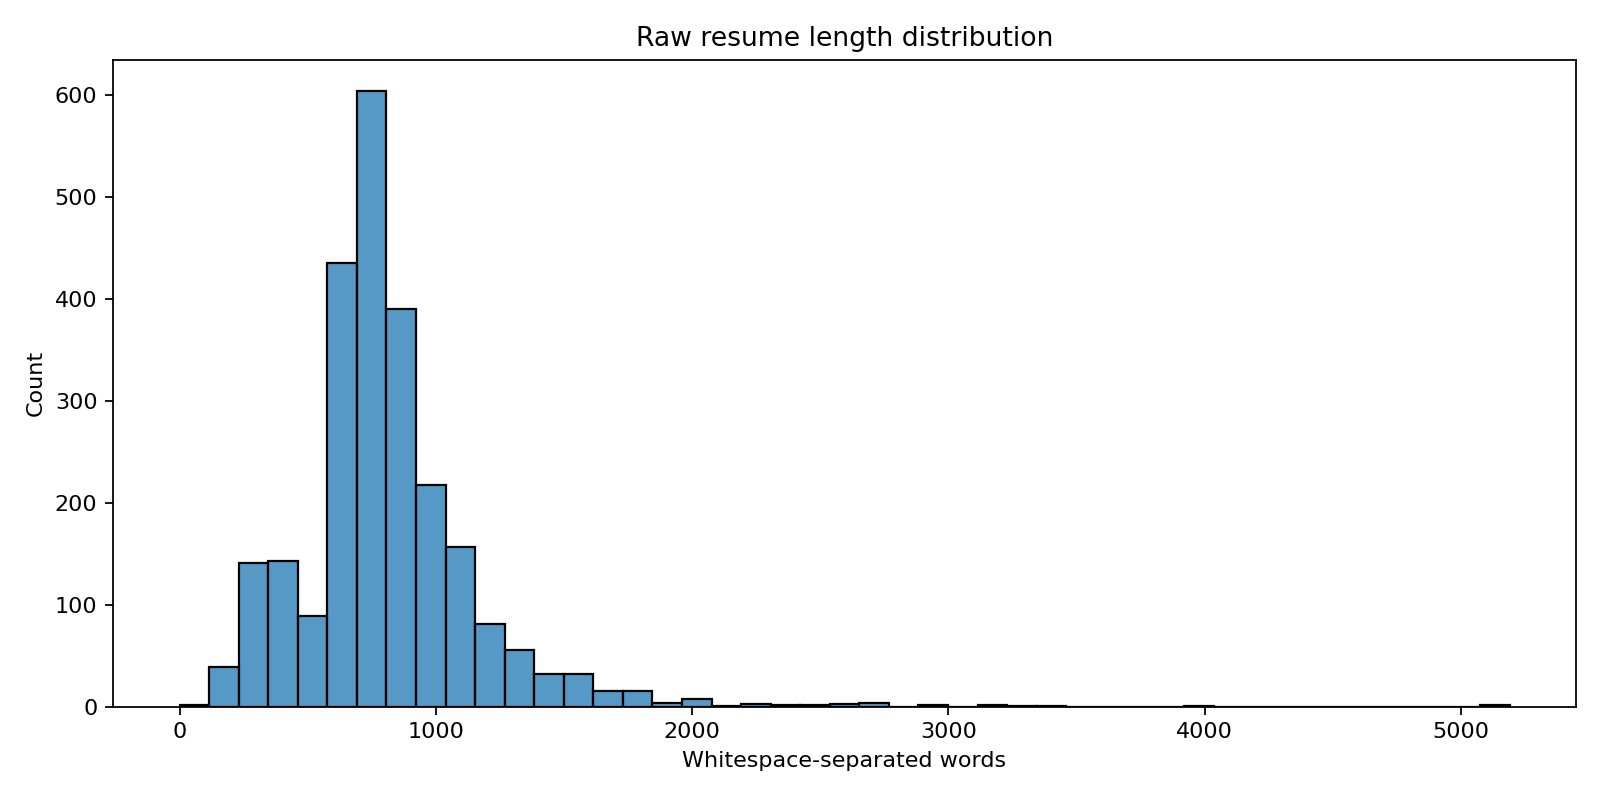

In [3]:
display(pd.Series(stats['word_length_statistics'], name='words'))
print('Exact duplicate raw texts:', stats['raw_exact_duplicate_texts'])
display(Image(filename=str(ROOT / 'reports/figures/text_lengths.png')))

## Frequent cleaned terms
These are descriptive token counts, not the fitted model vocabulary. Common resume boilerplate and explicit job titles can make this benchmark easier than unseen real-world resumes.

,ACCOUNTANT,ADVOCATE,AGRICULTURE,APPAREL,ARTS,AUTOMOBILE,AVIATION,BANKING,BPO,BUSINESS-DEVELOPMENT,...,DIGITAL-MEDIA,ENGINEERING,FINANCE,FITNESS,HEALTHCARE,HR,INFORMATION-TECHNOLOGY,PUBLIC-RELATIONS,SALES,TEACHER
accounting,1226,0,0,0,0,0,0,0,0,0,...,0,0,664,0,0,0,0,0,0,0
account,1117,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
financial,1081,0,0,0,0,0,0,0,0,0,...,0,0,1110,0,0,0,0,0,0,0
company,851,745,356,744,532,258,539,703,133,879,...,701,660,839,685,707,770,0,837,765,500
state,822,944,485,762,758,287,702,708,0,825,...,642,643,764,777,856,699,665,721,765,746
city,680,834,406,728,632,252,606,627,116,722,...,605,646,694,713,746,568,0,689,713,641
report,592,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
management,585,0,285,0,0,164,530,774,208,633,...,0,523,791,0,679,950,899,0,0,0
customer,0,1006,0,716,0,308,470,638,0,738,...,0,0,0,652,604,0,0,0,1427,0
service,0,802,0,0,0,250,0,604,117,0,...,0,0,0,511,598,0,0,0,669,0


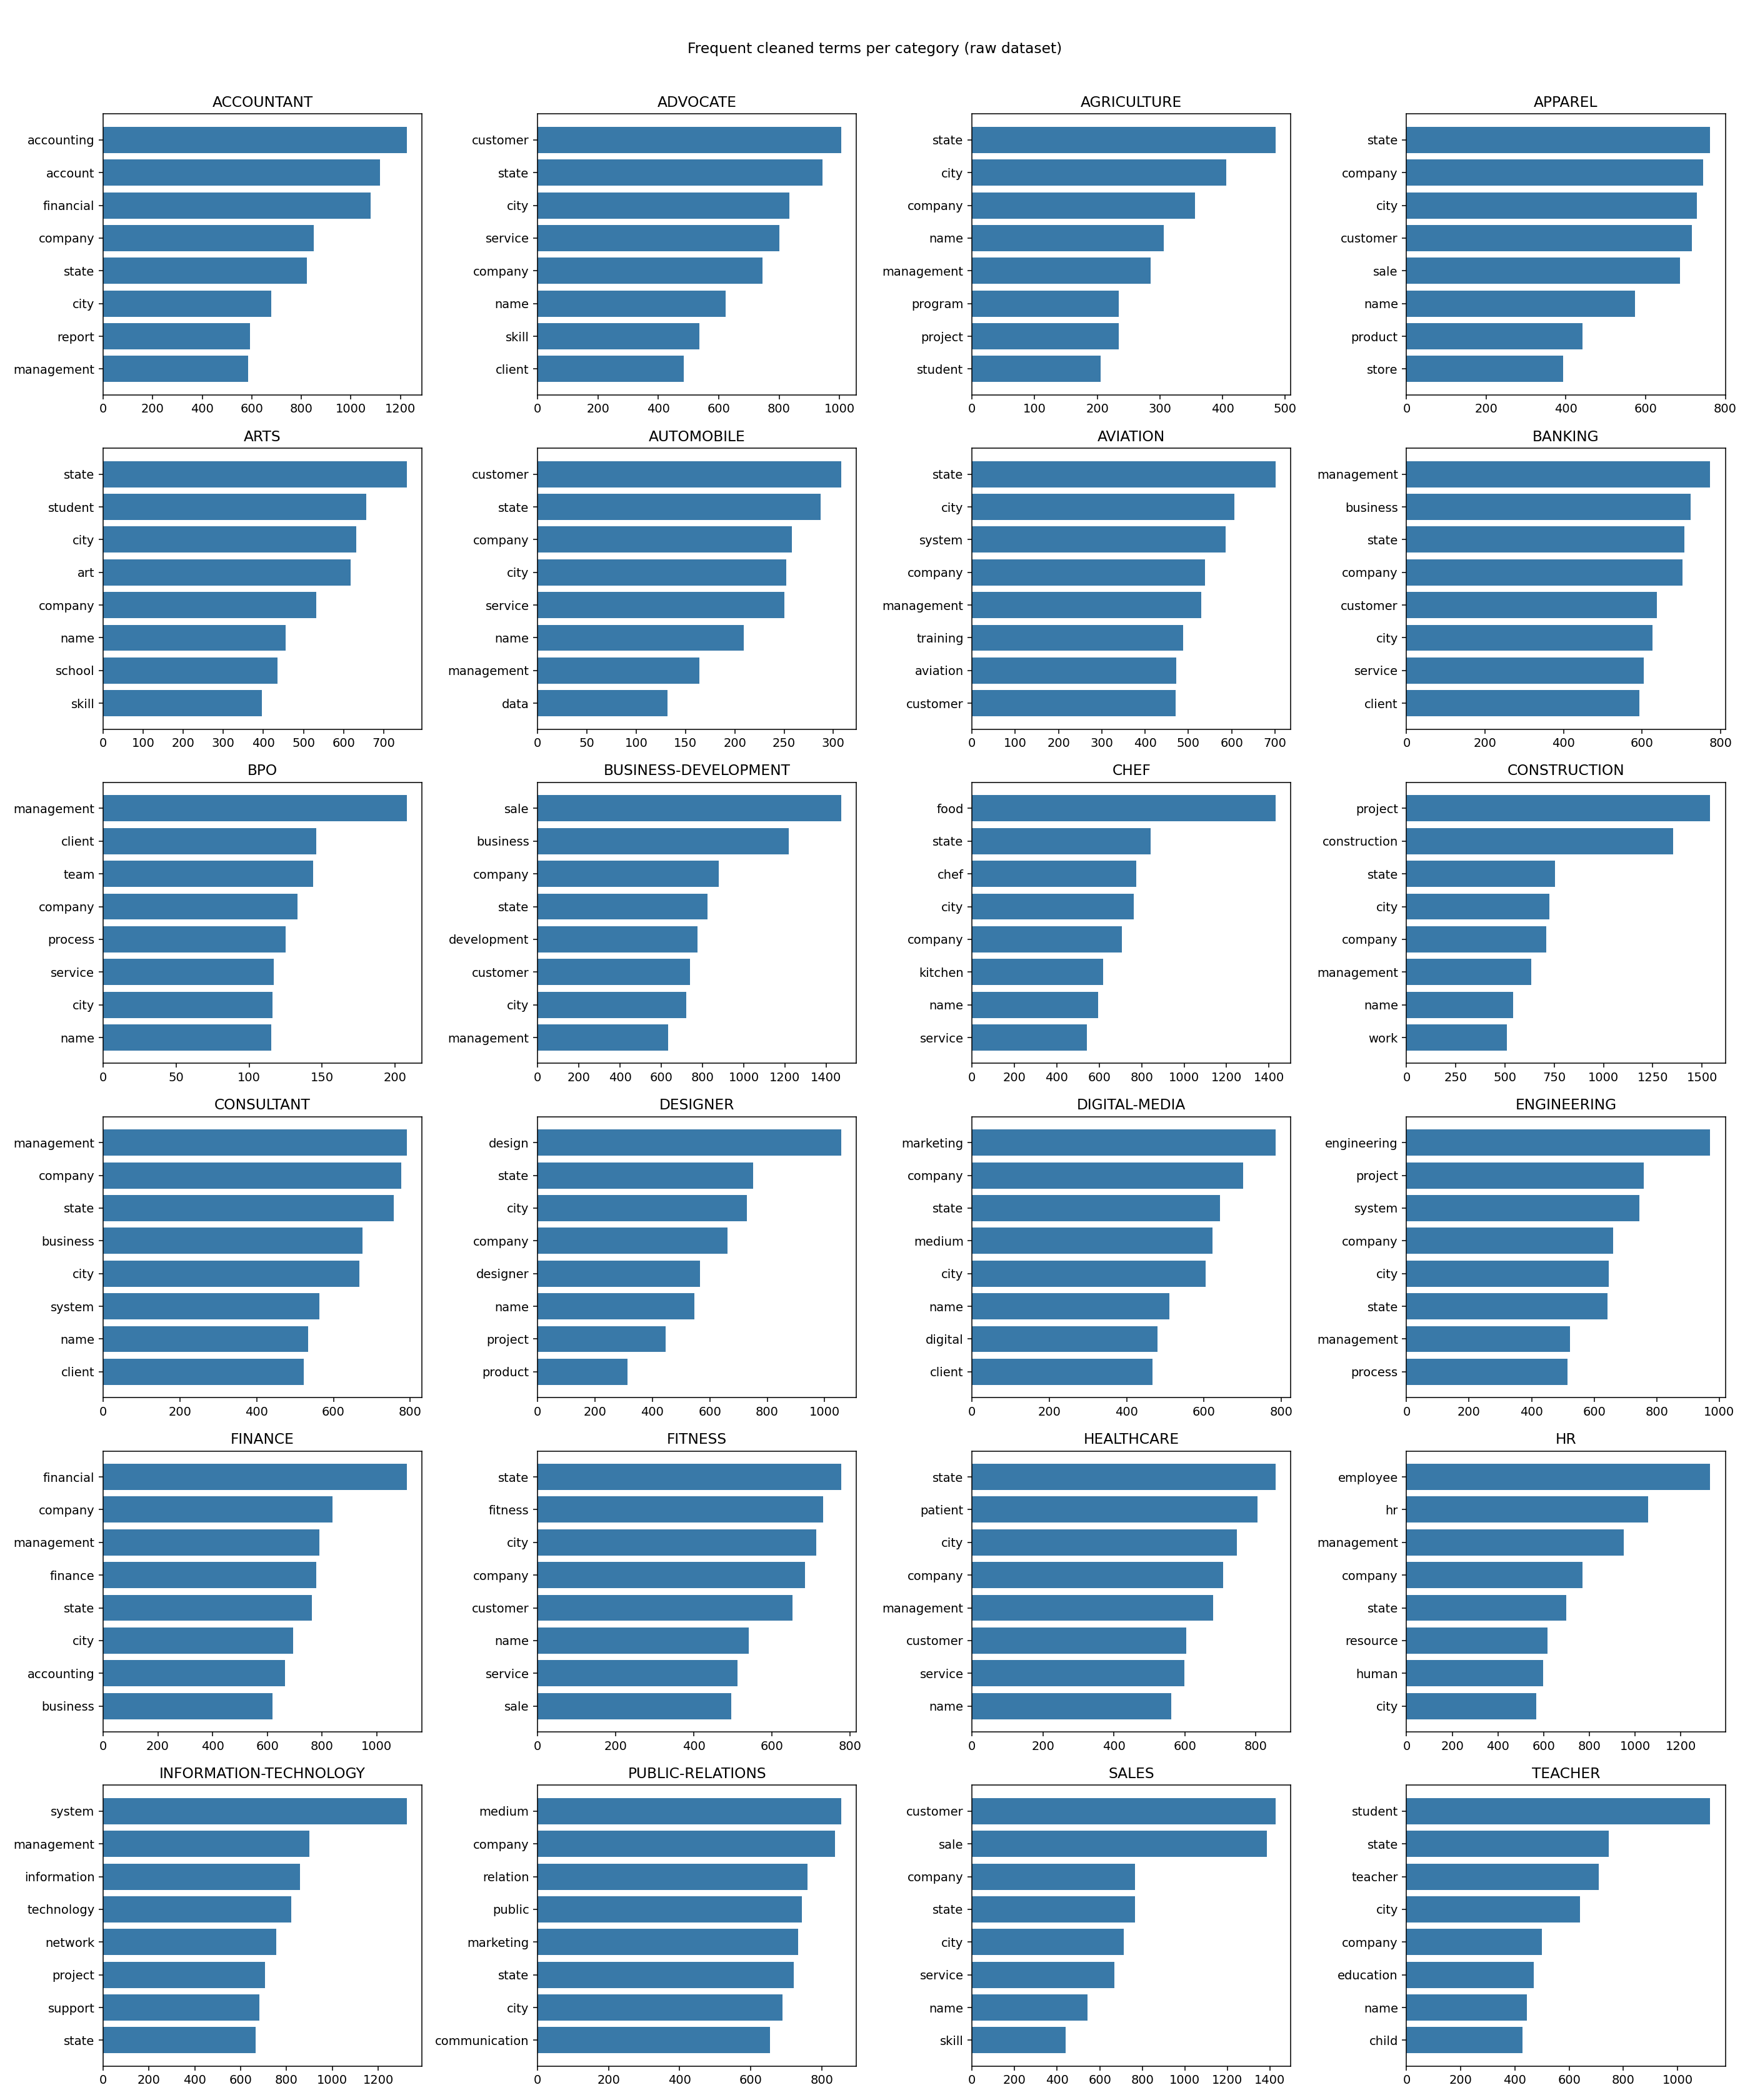

In [4]:
display(pd.DataFrame(stats['frequent_terms_per_category']).fillna(0).astype(int))
display(Image(filename=str(ROOT / 'reports/figures/frequent_terms.png')))

## Interpretation
The source is a single website-derived English corpus. Category overlap, small minority classes, duplicates and title cues limit generalization. See results.json for deduplication counts and held-out evaluation; EDA is not evidence of deployment performance.